# Кредитный скоринг

## Постановка задачи:
Провести исследовательский анализ данных:
- найти и обработать пропуски
- понять основные характеристики признаков
- обработать неверные значения и выбросы

## 1. Подготовка данных

## 1.1 Общий обзор

In [1]:
#загрузим библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
#считаем датасет
credit_df = pd.read_csv('../data/train.csv', index_col='ID')

C:\Users\79659\AppData\Local\Temp\ipykernel_7124\2268535609.py:2: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  credit_df = pd.read_csv('../data/train.csv', index_col='ID')


In [3]:
#отобразим
display(credit_df)

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor


In [4]:
# Проверим уникальные значения в столбце со смешанными типами данных
mixed_col = credit_df.columns[25]

print(f'Column: {mixed_col}')
print(credit_df[mixed_col].unique())

Column: Monthly_Balance
['312.49408867943663' '284.62916249607184' '331.2098628537912' ...
 516.8090832742814 319.1649785257098 393.6736955618808]


In [5]:
credit_df['Monthly_Balance'].value_counts(dropna=False)

Monthly_Balance
NaN                                 1200
__-333333333333333333333333333__       9
484.5912142650067                      1
393.673696                             1
312.49408867943663                     1
                                    ... 
300.008498                             1
396.997157                             1
368.154976                             1
412.669312                             1
432.559318                             1
Name: count, Length: 98793, dtype: int64

In [6]:
credit_df.loc[credit_df['Monthly_Balance'] == '__-333333333333333333333333333__']

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x367f,CUS_0x9885,February,Paul Dayl,17,186-49-9679,Developer,41086.4,3660.866667,3,4,...,Standard,113.98,34.826541,11 Years and 6 Months,Yes,145.544320,201.1429928919469,Low_spent_Medium_value_payments,__-333333333333333333333333333__,Standard
0xaf63,CUS_0x5a90,February,Scuffhamq,45,264-53-1943,Engineer,29728.31,2551.359167,3,4,...,Good,917.0,38.198076,31 Years and 9 Months,No,34.496445,198.6115126951797,Low_spent_Large_value_payments,__-333333333333333333333333333__,Good
0xc0d8,CUS_0x288d,July,Selamk,55,970-19-8342,Lawyer,30748.93,2572.410833,1,6,...,Good,860.97,40.634250,19 Years and 5 Months,No,43.727774,79.07180674947499,High_spent_Small_value_payments,__-333333333333333333333333333__,Standard
0xe66c,CUS_0x85e9,March,Anna Driveri,45,288-62-7562,_______,20929.295_,1704.107917,5,3,...,_,858.09,33.943626,21 Years and 7 Months,No,13798.000000,220.30455197823662,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
0xf84c,CUS_0x2b77,July,Longstretho,21,006-36-0111,Doctor,15167.62,1471.968333,4,5,...,Good,847.03,28.541848,NaN,NM,9.930809,128.87587207680795,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
0x1759f,CUS_0xc06e,February,radenp,30,046-72-5387,Journalist,92114.68,7811.223333,3,4,...,Standard,820.52,39.089475,20 Years and 10 Months,Yes,54.219664,NaN,High_spent_Large_value_payments,__-333333333333333333333333333__,Standard
0x1ceed,CUS_0x57f3,April,Kristen Haysq,29,577-85-0830,Mechanic,60904.59,NaN,3,4,...,Standard,2441.47,29.878716,12 Years and 11 Months,Yes,61.525140,394.8939566733383,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
0x1fbd8,CUS_0x41bf,July,Doeringq,44,693-64-7611,Journalist,61990.52,4900.876667,10,10,...,Bad,3618.91,37.718591,13 Years and 8 Months,NM,355.143396,194.28348839148083,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
0x1fdd1,CUS_0x2f7e,August,Sabina Zawadzkif,31,109-48-2095,Doctor,126353.04,10635.420000,4,7,...,_,859.77,28.442867,31 Years and 9 Months,No,167.043910,549.7661392945339,Low_spent_Medium_value_payments,__-333333333333333333333333333__,Poor


Видим, в чем проблема: в колонке есть некорректные значения, которые вызывают предупреждения Pandas. Их мы обработаем позже.

In [7]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 0x1602 to 0x25fed
Data columns (total 27 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Customer_ID               100000 non-null  object 
 1   Month                     100000 non-null  object 
 2   Name                      90015 non-null   object 
 3   Age                       100000 non-null  object 
 4   SSN                       100000 non-null  object 
 5   Occupation                100000 non-null  object 
 6   Annual_Income             100000 non-null  object 
 7   Monthly_Inhand_Salary     84998 non-null   float64
 8   Num_Bank_Accounts         100000 non-null  int64  
 9   Num_Credit_Card           100000 non-null  int64  
 10  Interest_Rate             100000 non-null  int64  
 11  Num_of_Loan               100000 non-null  object 
 12  Type_of_Loan              88592 non-null   object 
 13  Delay_from_due_date       100000 non-null  

В датафрейме 26 признаков и 1 целевая переменная.


1. пропуски в 8 столбцах


- 0   ID                         - идентификатор
- 1   Customer_ID               - идентификатор клиента 
-  2   Month                     - месяц 
-  3   Name                      - имя 
- 4   Age                       - возраст 
- 5   SSN                       - номер социального страхования
- 6   Occupation                - род деятельности 
- 7   Annual_Income             - ежегодный доход 
- 8   Monthly_Inhand_Salary     - ежемесячный доход без учета налогов
- 9   Num_Bank_Accounts         - количество банковских аккаунтов
- 10  Num_Credit_Card           - номер кредитной карты
- 11  Interest_Rate             - процентная ставка 
- 12  Num_of_Loan               - количество кредитов 
- 13  Type_of_Loan              - тип кредита 
- 14  Delay_from_due_date       - задержка срока платежа
- 15  Num_of_Delayed_Payment    - количество задержек
- 16  Changed_Credit_Limit      - изменение кредитного лимита
- 17  Num_Credit_Inquiries      - количество запросов кредита
- 18  Credit_Mix                - кредит мик
- 19  Outstanding_Debt          - непогашенный долг
- 20  Credit_Utilization_Ratio  - коэффициент использования кредита
- 21  Credit_History_Age        - протяженности кредитной истории 
- 22  Payment_of_Min_Amount     - минимальный платеж 
- 23  Total_EMI_per_month       - равномерные ежемесячные платежи
- 24  Amount_invested_monthly   - ежемесячные инвестиции 
- 25  Payment_Behaviour         - платежное поведение
- 26  Monthly_Balance           - ежемесячный баланс 
- 27  Credit_Score              - кредитный рейтинг

Посмотрим статистики по разным столбцам в зависимости от типа и проверим на дубликаты.

In [8]:
print(f'Количество дубликатов: {credit_df.duplicated().sum()}')

Количество дубликатов: 0


In [9]:
credit_df.select_dtypes(include='number').describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


In [10]:
credit_df.select_dtypes(include='object').describe()

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Num_of_Loan,Type_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000,100000,90015,100000,100000,100000,100000,100000,88592,92998,100000,100000,100000,90970,100000,95521,100000,98800,100000
unique,12500,8,10139,1788,12501,16,18940,434,6260,749,4384,4,13178,404,3,91049,7,98792,3
top,CUS_0x942c,January,Stevex,38,#F%$D@*&8,_______,17273.83,3,Not Specified,19,_,Standard,1360.45,15 Years and 11 Months,Yes,__10000__,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
freq,8,12500,44,2833,5572,7062,16,14386,1408,5327,2091,36479,24,446,52326,4305,25513,9,53174


Сразу замечаем, что у столбцов с числовыми значениями тип данных object, есть некорректные значения. Данным необходима перекодировка и очистка.
Рассмотрим каждый столбец отдельно и проведем анализ.


## Анализ признаков

У нас есть две дублирующие друг друга строки Customer-ID и ID. 

In [11]:
print(f'Количество уникальных значений для Customer-ID: {len(credit_df['Customer_ID'].unique())}')
print(f'Количество пропусков для Custome-ID {credit_df['Customer_ID'].isna().sum()}')

Количество уникальных значений для Customer-ID: 12500
Количество пропусков для Custome-ID 0


In [12]:
print(f'Есть ли пропуски в индексе: {credit_df.index.hasnans}')
print(f'Содержатся ли в индексе уникальные значения: {credit_df.index.nunique()}')

Есть ли пропуски в индексе: False
Содержатся ли в индексе уникальные значения: 100000


Датафрейм содержит данные о 12500 клиентах. В качестве индекса используется идентификтор, уникальный для каждой строки. Он не информативен и его можно удалить без потери информации.

In [13]:
#посмотрим, сколько у нас уникальных значений в категории месяц
print(f'уникальный значений в категории месяц: {len(credit_df["Month"].unique())}')
print(*credit_df['Month'].unique(), sep='\n')

уникальный значений в категории месяц: 8
January
February
March
April
May
June
July
August


в датафрейме представленные данные 12500 клиентов за восемь полных месяцев.

In [14]:
#так как часть данных вметсо числовых форматов представлена в object напишем функцию для удаления нечисловых символов из количественных данных
def numeric(x):
    x = list(x)
    for i in x:
        if i in '.1234567890':
            continue
        else:
            x.remove(i)
    return ''.join(x)

In [15]:
#применим функцию numeric к столбцу age
credit_df['Age'] = credit_df['Age'].apply(numeric)
#поменяем тип данных категори возраст на int и посмотрим их распределение
credit_df['Age'] = credit_df['Age'].astype(int)

In [16]:
#проверим работу функции
credit_df['Age']

ID
0x1602      23
0x1603      23
0x1604     500
0x1605      23
0x1606      23
          ... 
0x25fe9     25
0x25fea     25
0x25feb     25
0x25fec     25
0x25fed     25
Name: Age, Length: 100000, dtype: int64

In [17]:
print(f'Количество пропусков в графе возраст {credit_df['Age'].isna().sum()}')

Количество пропусков в графе возраст 0


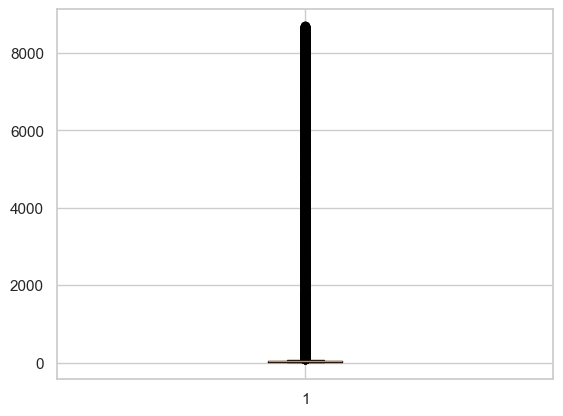

In [18]:
plt.boxplot(x='Age', data=credit_df)
plt.show()

In [19]:
credit_df['Age'].describe()

count    100000.000000
mean        119.509700
std         684.757313
min          14.000000
25%          25.000000
50%          34.000000
75%          42.000000
max        8698.000000
Name: Age, dtype: float64

Статистики и боксплот показывают, что у нас скошенное распределение и большой хвост выбросов. Почистим данные: нужно удалить клиентов, чей возраст выходит за диапазон от нуля до сто десяти. Также проверить, чтобы у каждого клиента был один возраст или разница между возрастами была не более одного года (в датафрейме представлены данные только за один календарный год)

In [20]:
#отфильтруем возраст клиентов от 0 до 100, чтобы избавится от выбросов
age_df = credit_df[(credit_df['Age'] > 0) & (credit_df['Age'] <= 110)][['Age', 'Customer_ID']]
age_df = age_df.reset_index(drop=True).drop_duplicates()
age_df

,Age,Customer_ID
0,23,CUS_0xd40
7,28,CUS_0x21b1
15,34,CUS_0x2dbc
23,54,CUS_0xb891
25,55,CUS_0xb891
...,...,...
97207,50,CUS_0xaf61
97210,28,CUS_0x8600
97217,29,CUS_0x8600
97218,24,CUS_0x942c


In [21]:
age_df.groupby('Customer_ID')['Age'].nunique().sort_values(ascending=False).head()

Customer_ID
CUS_0xffd     2
CUS_0x1000    2
CUS_0x1009    2
CUS_0x100b    2
CUS_0xfb8     2
Name: Age, dtype: int64

In [22]:
problem_clients = age_df.groupby('Customer_ID')['Age'].nunique()
problem_clients = problem_clients[problem_clients > 1]

print(problem_clients)

Customer_ID
CUS_0x1000    2
CUS_0x1009    2
CUS_0x100b    2
CUS_0x1011    2
CUS_0x1013    2
             ..
CUS_0xfe5     2
CUS_0xff4     2
CUS_0xff6     2
CUS_0xffc     2
CUS_0xffd     2
Name: Age, Length: 7205, dtype: int64


In [23]:
age_df.groupby('Customer_ID')['Age'].unique().loc[problem_clients.index]

Customer_ID
CUS_0x1000    [17, 18]
CUS_0x1009    [25, 26]
CUS_0x100b    [18, 19]
CUS_0x1011    [43, 44]
CUS_0x1013    [43, 44]
                ...   
CUS_0xfe5     [37, 38]
CUS_0xff4     [36, 37]
CUS_0xff6     [18, 19]
CUS_0xffc     [17, 18]
CUS_0xffd     [29, 30]
Name: Age, Length: 7205, dtype: object

Как мы можем видеть возраст у проблемных клиентов отличается на 1, скорее всего у клиента было день рождение. Соберем тех клиентов, у кого разница в дне рождении составляет больше 1 года.

In [24]:
(
    age_df.groupby('Customer_ID')['Age']
    .agg(lambda x: max(x) - min(x))
    .value_counts()
)

Age
1     7198
0     5295
68       2
71       1
67       1
61       1
63       1
44       1
Name: count, dtype: int64

In [25]:
age_diff = (
    age_df.groupby('Customer_ID')['Age']
    .agg(lambda x: max(x) - min(x))
)

problem_ids = age_diff[age_diff > 1]

print(problem_ids)

Customer_ID
CUS_0x1dd3    71
CUS_0x3b9a    68
CUS_0x4b64    67
CUS_0x51cb    61
CUS_0x7e94    63
CUS_0xc24a    68
CUS_0xdc8     44
Name: Age, dtype: int64


In [26]:
age_df[
    age_df['Customer_ID'].isin(problem_ids.index)
].sort_values('Customer_ID')

,Age,Customer_ID
76379,24,CUS_0x1dd3
76383,95,CUS_0x1dd3
28505,32,CUS_0x3b9a
28509,100,CUS_0x3b9a
30437,102,CUS_0x4b64
30438,35,CUS_0x4b64
54630,48,CUS_0x51cb
54635,109,CUS_0x51cb
37191,95,CUS_0x7e94
37192,32,CUS_0x7e94


In [27]:
credit_df.loc[
    credit_df['Customer_ID'].isin(problem_ids.index),
    ['Customer_ID', 'Name', 'Age']
].sort_values(['Customer_ID', 'Age'])

,Customer_ID,Name,Age
ID,,,
0x1e252,CUS_0x1dd3,Gerryg,24
0x1e253,CUS_0x1dd3,Gerryg,24
0x1e254,CUS_0x1dd3,Gerryg,24
0x1e255,CUS_0x1dd3,Gerryg,24
0x1e257,CUS_0x1dd3,Gerryg,24
0x1e258,CUS_0x1dd3,Gerryg,24
0x1e259,CUS_0x1dd3,Gerryg,24
0x1e256,CUS_0x1dd3,Gerryg,95
0xc1c2,CUS_0x3b9a,NaN,32


In [28]:
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0x1dd3', 'Age'] = 24
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0x3b9a', 'Age'] = 32
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0x4b64', 'Age'] = 35
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0x51cb', 'Age'] = 48
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0x7e94', 'Age'] = 32
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0xc24a', 'Age'] = 31
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0xdc8', 'Age'] = 51


In [29]:
credit_df

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
0x1604,CUS_0xd40,March,Aaron Maashoh,500,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor


In [30]:
rate_of_incorret_age = (1 - len(credit_df.loc[(credit_df['Age'] > 0) & (credit_df['Age'] < 105)])/len(credit_df))
print(f'Доля некорректных данных по возрасту: {rate_of_incorret_age:.2%}')

Доля некорректных данных по возрасту: 2.77%


Мы можем удалить некорректные данные, так как их величина не значительна.

In [31]:
credit_df = credit_df.loc[(credit_df['Age'] > 0) & (credit_df['Age'] < 105)]
credit_df = credit_df.copy()

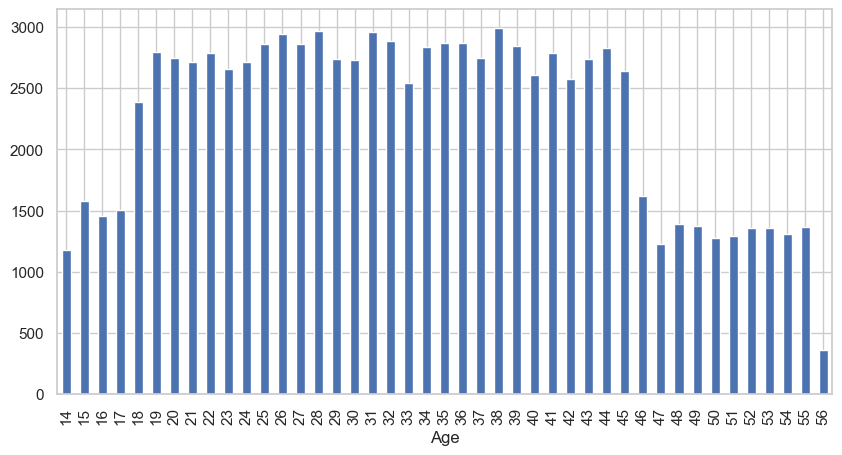

In [32]:
age_group = credit_df.groupby(by='Age')['Age'].count()
age_group.plot(kind='bar', grid=True, figsize=(10, 5))
plt.show()

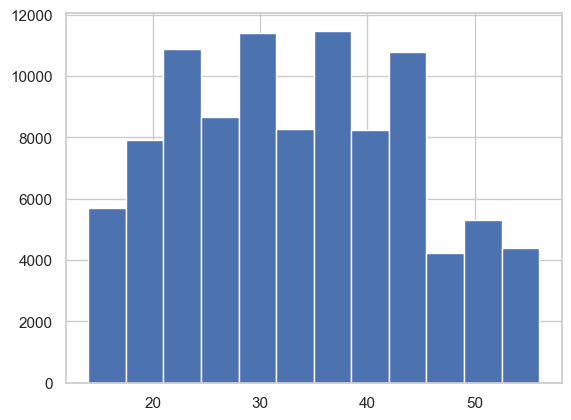

In [33]:
plt.hist(credit_df['Age'], bins=12)
plt.show()

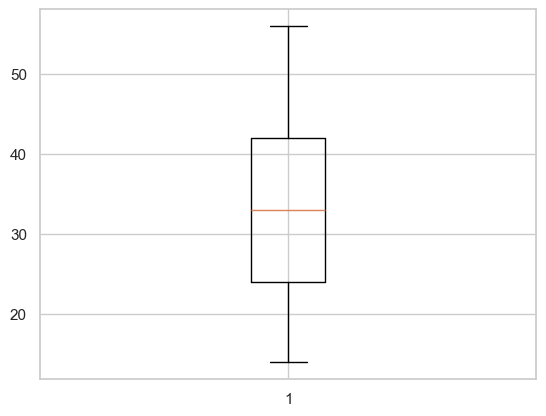

In [34]:
plt.boxplot(x='Age', data=credit_df)
plt.show()

In [35]:
credit_df['Age'].describe()

count    97227.000000
mean        33.320364
std         10.769517
min         14.000000
25%         24.000000
50%         33.000000
75%         42.000000
max         56.000000
Name: Age, dtype: float64

**Выводы по графе возраст** 
- датафрейм очищен от некорректных значений меньше 0 и больше 105.
- исправлены ошибки по неккоректному отображению возраста
- среднее значение возраста клиента - 33 года, самому младшему клиенту 14, самому старшему 56

In [36]:
#Annual Income
credit_df['Annual_Income'] = credit_df['Annual_Income'].apply(numeric)
credit_df['Annual_Income'] = credit_df['Annual_Income'].astype(float)

In [37]:
credit_df['Annual_Income'].describe()

count    9.722700e+04
mean     1.768399e+05
std      1.432660e+06
min      7.005930e+03
25%      1.946292e+04
50%      3.757975e+04
75%      7.281702e+04
max      2.419806e+07
Name: Annual_Income, dtype: float64

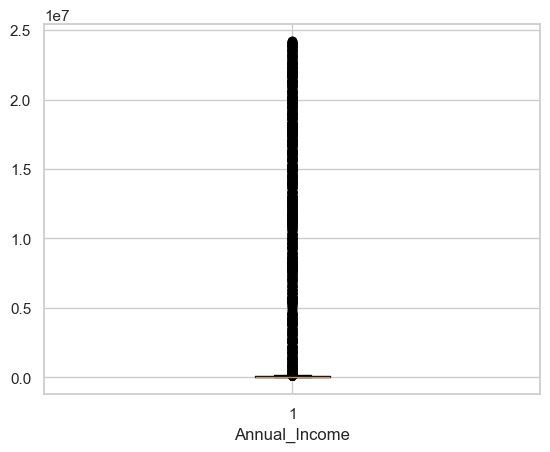

In [38]:
plt.boxplot(x='Annual_Income', data=credit_df)
plt.xlabel('Annual_Income')
plt.show()

In [39]:
#посмотрим ежегодный и ежемесячный доход по профессиям
occupation_annual_income_df = credit_df.pivot_table(index='Occupation', 
                                                    values=['Annual_Income', 
                                                            'Monthly_Inhand_Salary']).round(2).sort_values(by='Annual_Income')

In [40]:
occupation_annual_income_df

,Annual_Income,Monthly_Inhand_Salary
Occupation,,
Writer,156762.14,4253.40
Journalist,158253.00,4016.74
Manager,159540.34,4289.78
Teacher,165034.62,4117.45
Architect,171416.13,4287.63
Engineer,171942.78,4241.54
Mechanic,172387.75,4152.92
Developer,172732.70,4150.71
Scientist,176650.52,4260.10


In [41]:
occupation_annual_income_median_df = credit_df.pivot_table(index='Occupation', 
                                                    values=['Annual_Income', 
                                                            'Monthly_Inhand_Salary'], aggfunc='median').round(2)

In [42]:
#посмотрим медиану
occupation_annual_income_median_df.sort_values(by='Annual_Income', ascending=False)

,Annual_Income,Monthly_Inhand_Salary
Occupation,,
Scientist,40019.64,3260.46
Manager,39191.16,3245.01
Engineer,39133.63,3201.51
Accountant,38897.52,3204.21
Musician,38868.12,3130.68
Architect,38261.70,3151.26
Writer,37993.12,3166.96
Media_Manager,37813.29,3144.38
Entrepreneur,37777.92,3120.32


In [43]:
credit_df['Num_Bank_Accounts'].describe()

count    97227.000000
mean        17.127722
std        117.685312
min         -1.000000
25%          3.000000
50%          6.000000
75%          7.000000
max       1798.000000
Name: Num_Bank_Accounts, dtype: float64

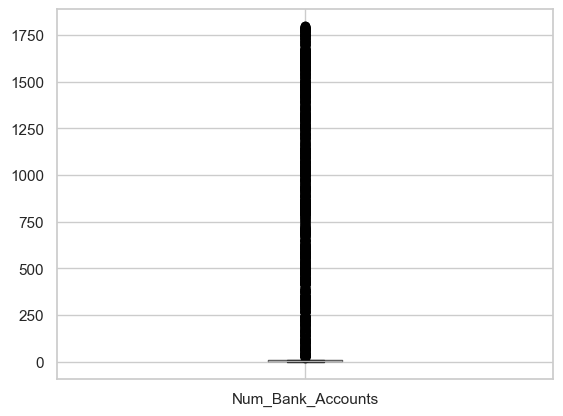

In [44]:
credit_df[['Num_Bank_Accounts']].boxplot()
plt.show()

In [45]:
credit_df.loc[credit_df['Num_Bank_Accounts'] > 20]

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x1791,CUS_0x4004,April,Carlosj,44,679-26-6464,Writer,58317.00,NaN,1414,5,...,Standard,98.97,29.766107,NaN,Yes,149.897199,158.64827595455043,High_spent_Medium_value_payments,407.9295246244412,Standard
0x17d0,CUS_0x42ac,July,Lawrencea,37,700-60-3660,Musician,15566.02,1423.168333,67,5,...,Standard,1693.95,29.706454,8 Years and 4 Months,Yes,43.070520,80.48442010154183,!@9#%8,308.76189362947565,Poor
0x17fd,CUS_0x9bc1,April,Jaisinghanij,42,445-18-4420,_______,20574.47,NaN,572,3,...,Standard,749.95,36.559538,11 Years and 2 Months,Yes,49.348666,25.161404432750263,High_spent_Medium_value_payments,349.54384591241774,Standard
0x1816,CUS_0xaedb,May,Olivia Oranr,19,272-47-1135,Musician,85554.03,7185.502500,1488,2,...,_,1095.73,41.661802,19 Years and 11 Months,No,0.000000,70.82263261910934,High_spent_Large_value_payments,887.7276173808908,Good
0x1a6e,CUS_0x8643,May,Steve Slatery,33,198-08-9791,Musician,14205.09,1086.757500,91,10,...,Bad,4845.24,30.989504,NaN,Yes,49.032395,64.58804984795468,Low_spent_Large_value_payments,265.05530468293233,Standard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0x25d89,CUS_0x544,August,Jon Herskovitzu,29,163-45-1172,Mechanic,17013.29,1326.774167,813,1,...,_,1452.79,28.051684,32 Years and 6 Months,NM,13.109663,55.72695329443804,Low_spent_Small_value_payments,353.840801,Good
0x25dd0,CUS_0x296f,July,David Millikenh,25,972-13-0672,Developer,125271.96,10374.330000,1481,7,...,Good,827.56,33.201730,25 Years and 8 Months,NM,241.065885,180.56001463373025,!@9#%8,855.8071,Poor
0x25dfc,CUS_0xb09,March,Lianau,31,228-47-4867,Lawyer,146310.68,12124.556667,474,4,...,Good,928.28,43.274889,22 Years and 3 Months,No,72.250125,121.28482498252883,High_spent_Large_value_payments,1258.920717,Standard


In [46]:
credit_df.loc[credit_df['Num_Bank_Accounts'] < 0]

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0xc7b8,CUS_0x4f2a,March,Margaretf,39,807-03-5415,Engineer,128305.76,10434.146667,-1,6,...,Good,1151.7,40.586736,22 Years and 5 Months,No,196.587321,230.9223857499363,High_spent_Large_value_payments,855.9049597507532,Standard
0xc7b9,CUS_0x4f2a,April,Margaretf,40,#F%$D@*&8,Engineer,128305.76,NaN,-1,6,...,Good,1151.7_,39.369401,22 Years and 6 Months,No,196.587321,524.3044177743545,Low_spent_Large_value_payments,592.522927726335,Good
0xc7ba,CUS_0x4f2a,May,Margaretf,40,807-03-5415,Engineer,128305.76,10434.146667,-1,6,...,Good,1151.7,28.702053,22 Years and 7 Months,No,196.587321,150.0966753535676,High_spent_Large_value_payments,936.7306701471217,Good
0xc7bb,CUS_0x4f2a,June,Margaretf,40,807-03-5415,Engineer,128305.76,10434.146667,-1,6,...,Good,1151.7,34.808390,22 Years and 8 Months,No,196.587321,1006.6980690205388,Low_spent_Medium_value_payments,120.12927648015079,Good
0xc7bc,CUS_0x4f2a,July,Margaretf,40,807-03-5415,Engineer,128305.76,10434.146667,-1,6,...,Good,1151.7,35.206427,NaN,No,42850.000000,172.99202124673786,High_spent_Large_value_payments,913.8353242539515,Good
0xc7bd,CUS_0x4f2a,August,Margaretf,40,807-03-5415,Engineer,22136920.00,NaN,-1,6,...,_,1151.7,38.278518,22 Years and 10 Months,No,196.587321,338.67230317776176,High_spent_Medium_value_payments,758.1550423229277,Good
0x115ff,CUS_0xa878,February,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.922500,-1,6,...,Good,607.78,37.286105,20 Years and 6 Months,No,0.000000,668.1444536762707,!@9#%8,588.9477963237292,Poor
0x11600,CUS_0xa878,March,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.922500,-1,6,...,Good,607.78,41.915627,20 Years and 7 Months,No,0.000000,142.31978881674561,High_spent_Large_value_payments,1084.7724611832548,Poor
0x11601,CUS_0xa878,April,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.922500,-1,6,...,Good,607.78,41.799942,20 Years and 8 Months,No,0.000000,467.563922615828,High_spent_Small_value_payments,779.528327384172,Poor
